In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

In [40]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

**Carrega os dados**

In [41]:
oecd_bli = pd.read_csv("../datas/oecd_bli_2015.csv", thousands=',')
gdp_per_capita = pd.read_csv(
    "../datas/gdp_per_capita.csv",
    thousands=',',
    delimiter='\t',
    encoding='latin1', 
    na_values="n/a"
)
gdp_per_capita.columns = gdp_per_capita.columns.str.replace('\ufeff', '').str.strip()

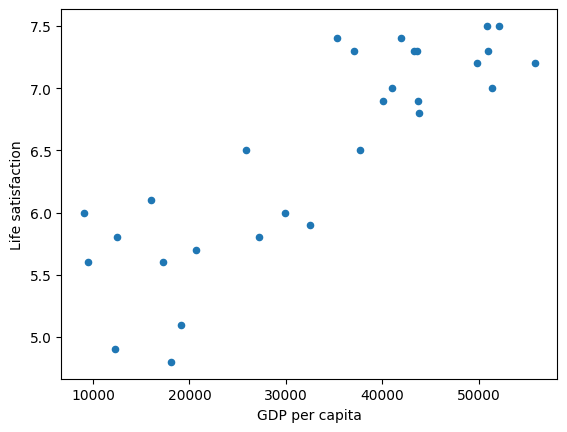

In [42]:
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()


In [43]:
# Seleciona o modelo de regressão linear:

In [44]:
model = sklearn.linear_model.LinearRegression()


In [45]:
#Treina o modelo:
model.fit(X, y)
# Faz uma predição para o PIB PerCapta do Brasil:
x_New = [[53886]]
print(model.predict(x_New))

[[7.49968772]]


**Aprendizado baseado em modelo:**

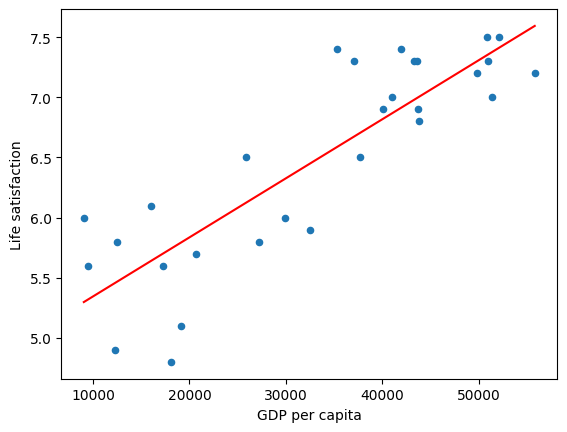

In [46]:
country_stats.plot(kind='scatter', x="GDP per capita", y="Life satisfaction")
plt.plot(X, model.predict(X), color='red')
plt.show()

 **Com modelo de regressão k-ésimo vizinho mais próximo:**

In [47]:
import sklearn.neighbors
modelKNN = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)
modelKNN.fit(X, y)
print(modelKNN.predict(x_New))


[[7.23333333]]


**Aprendizado baseado em instâncias:**

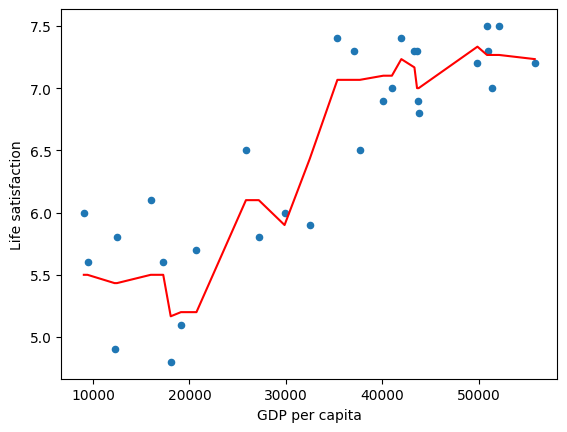

In [48]:
country_stats.plot(kind='scatter', x="GDP per capita", y="Life satisfaction")
plt.plot(X, modelKNN.predict(X), color='red')
plt.show()